# MARKET FUNNEL & CONVERSION PERFORMANCE ANALYSIS
# BY COLINS NDWIGA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline


## Data Source: I downloaded the Dataset From https://archive.ics.uci.edu/dataset/222/bank+marketing

In [3]:
df=pd.read_csv('bank-full.csv',low_memory=False)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Checking for null values

In [4]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### Checking the Datatypes

In [5]:
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [7]:
# Rename target column for clarity
df = df.rename(columns={'y': 'Subscribed'})

# Convert target to binary
df['Subscribed'] = df['Subscribed'].map({'yes': 1, 'no': 0})

# Basic statistics
print("Numerical Features Summary:")
display(df.describe())

print("\nCategorical Features Summary:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

Numerical Features Summary:


,age,balance,day,duration,campaign,pdays,previous,Subscribed
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000



Categorical Features Summary:
job: 12 unique values
marital: 3 unique values
education: 4 unique values
default: 2 unique values
housing: 2 unique values
loan: 2 unique values
contact: 3 unique values
month: 12 unique values
poutcome: 4 unique values


C:\Users\user\AppData\Local\Temp\ipykernel_8828\3919426069.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## Overall Conversion Rate

In [8]:
conversion_rate = df['Subscribed'].mean() * 100
print(f"Overall Subscription (Conversion) Rate: {conversion_rate:.2f}%")
print(f"Total Contacts: {len(df):,}")
print(f"Successful Subscriptions: {df['Subscribed'].sum():,}")

Overall Subscription (Conversion) Rate: 11.70%
Total Contacts: 45,211
Successful Subscriptions: 5,289


## Campaign Performance By Key Segment

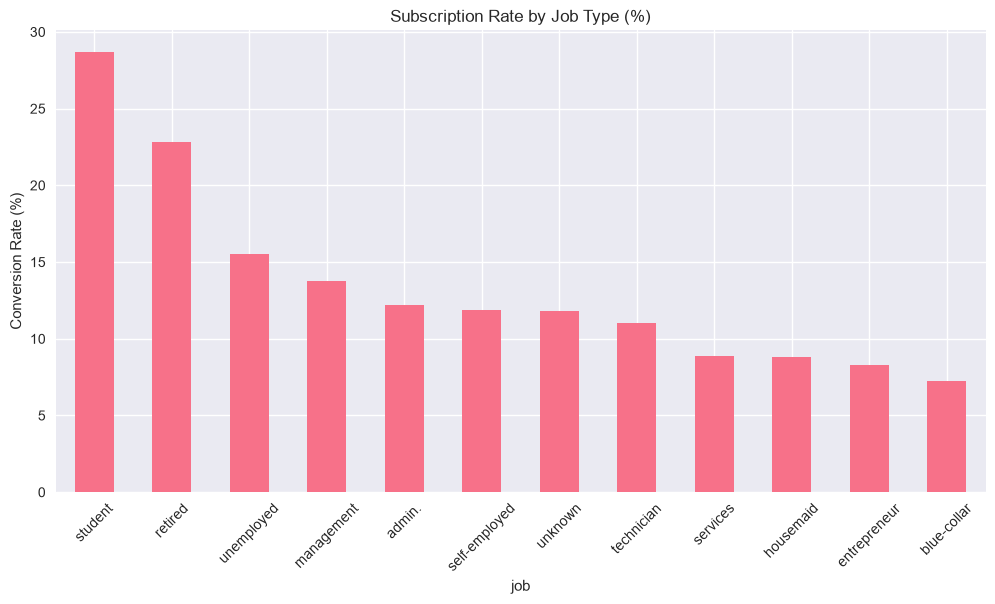

Top 5 Jobs by Conversion Rate:
job
student       28.678038
retired       22.791519
unemployed    15.502686
management    13.755551
admin.        12.202669
Name: Subscribed, dtype: float64


In [9]:
# Subscription rate by Job
plt.figure(figsize=(12, 6))
job_conv = df.groupby('job')['Subscribed'].mean() * 100
job_conv.sort_values(ascending=False).plot(kind='bar')
plt.title('Subscription Rate by Job Type (%)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.show()

print("Top 5 Jobs by Conversion Rate:")
print(job_conv.sort_values(ascending=False).head())

### Key Insight
### Students and retirees show the highest conversion rates (28.7% and 22.8% respectively), while blue-collar workers have the lowest. This suggests that campaign messaging and offers should be tailored differently across job segments, with students and retirees being high-potential targets.

## Conversion by Contact Method (Channel Performance)

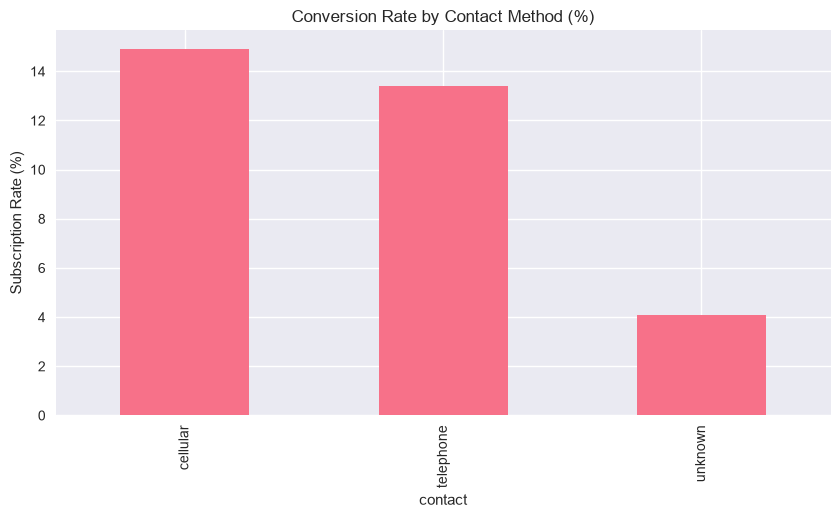

Conversion Rate by Contact Method:
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: Subscribed, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
channel_conv = df.groupby('contact')['Subscribed'].mean() * 100
channel_conv.sort_values(ascending=False).plot(kind='bar')
plt.title('Conversion Rate by Contact Method (%)')
plt.ylabel('Subscription Rate (%)')
plt.show()

print("Conversion Rate by Contact Method:")
print(channel_conv.round(2))

### Key Insight
### Cellular contact has the highest conversion rate at 14.9%, significantly outperforming unknown contact methods (4.1%). This highlights the importance of having up-to-date mobile numbers and prioritizing phone-based outreach over other channels.

### Conversion by Previous Campaign Outcome

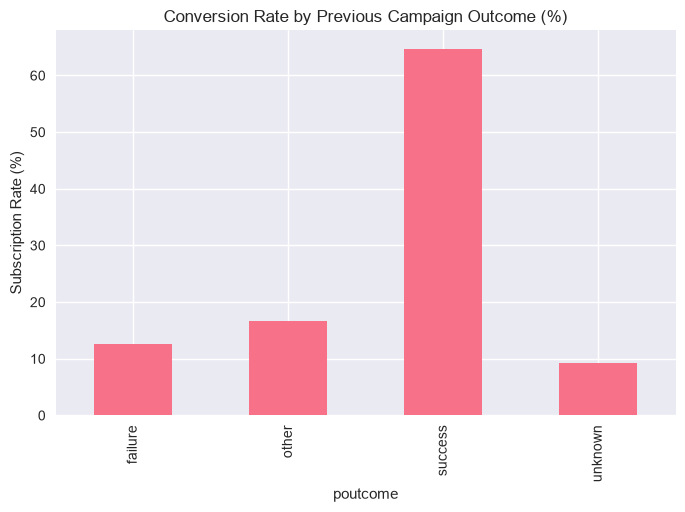


Conversion by Previous Outcome:
poutcome
failure    12.61
other      16.68
success    64.73
unknown     9.16
Name: Subscribed, dtype: float64


In [11]:
plt.figure(figsize=(8, 5))
poutcome_conv = df.groupby('poutcome')['Subscribed'].mean() * 100
poutcome_conv.plot(kind='bar')
plt.title('Conversion Rate by Previous Campaign Outcome (%)')
plt.ylabel('Subscription Rate (%)')
plt.show()

print("\nConversion by Previous Outcome:")
print(poutcome_conv.round(2))

### Key 
### Customers with a previous success have an extremely high conversion rate of 64.7% — over 5x the overall average. This strongly supports implementing strong re-targeting and nurturing strategies for past positive responders.

## Call Duration Analysis 

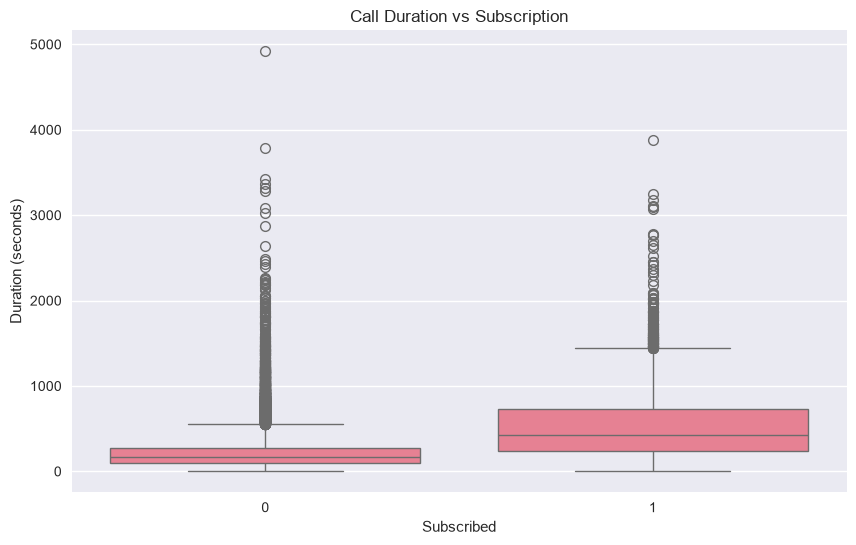


Average Call Duration:
Subscribed
0    221.18
1    537.29
Name: duration, dtype: float64


In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Subscribed', y='duration', data=df)
plt.title('Call Duration vs Subscription')
plt.ylabel('Duration (seconds)')
plt.show()

print("\nAverage Call Duration:")
print(df.groupby('Subscribed')['duration'].mean().round(2))

### Key Insight
### Successful subscriptions are associated with much longer call durations (average 537 seconds vs 221 seconds for non-subscribers). This indicates that deeper, more engaging conversations significantly increase the likelihood of conversion.

## Customer Demographics & Financial Insights

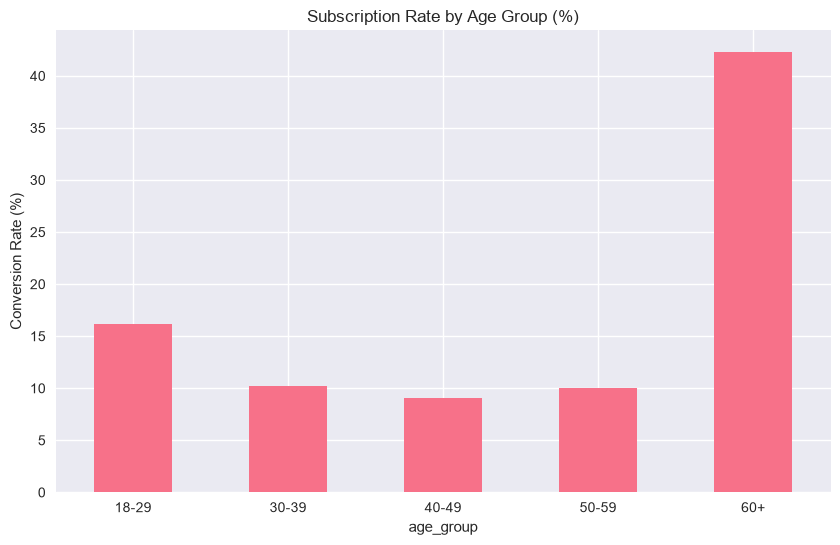

Conversion Rate by Age Group:
age_group
18-29    16.22
30-39    10.24
40-49     9.07
50-59    10.05
60+      42.26
Name: Subscribed, dtype: float64


In [13]:
# 1. Conversion Rate by Age Group
df['age_group'] = pd.cut(df['age'], 
                         bins=[18, 30, 40, 50, 60, 100], 
                         labels=['18-29', '30-39', '40-49', '50-59', '60+'])

age_conv = df.groupby('age_group')['Subscribed'].mean() * 100

plt.figure(figsize=(10, 6))
age_conv.plot(kind='bar')
plt.title('Subscription Rate by Age Group (%)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.show()

print("Conversion Rate by Age Group:")
print(age_conv.round(2))

### Key Insight
### The 60+ age group has the highest conversion rate at 42.3%, far above other groups. Older customers are significantly more receptive to the term deposit offer, making them a priority segment for future campaigns.

## Conversion by Marital Status & Education

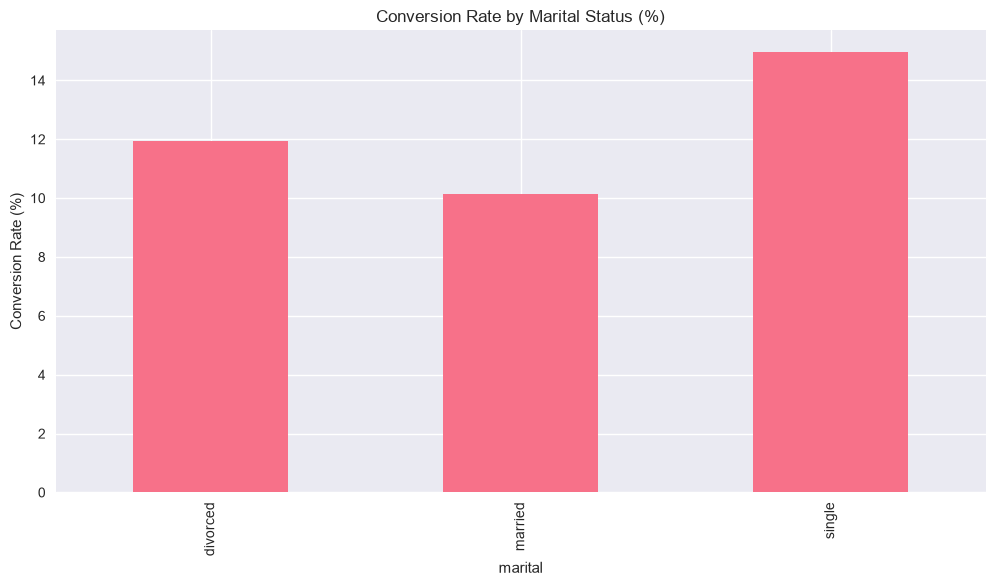


Conversion by Marital Status:
marital
divorced    11.95
married     10.12
single      14.95
Name: Subscribed, dtype: float64


In [15]:
plt.figure(figsize=(12, 6))
marital_conv = df.groupby('marital')['Subscribed'].mean() * 100
marital_conv.plot(kind='bar')
plt.title('Conversion Rate by Marital Status (%)')
plt.ylabel('Conversion Rate (%)')
plt.show()

print("\nConversion by Marital Status:")
print(marital_conv.round(2))

### Key Insight
### Single customers show a higher conversion rate (14.95%) compared to married (10.12%) and divorced customers. Marketing efforts may need to address different life-stage priorities across marital statuses.

## Balance Analysis

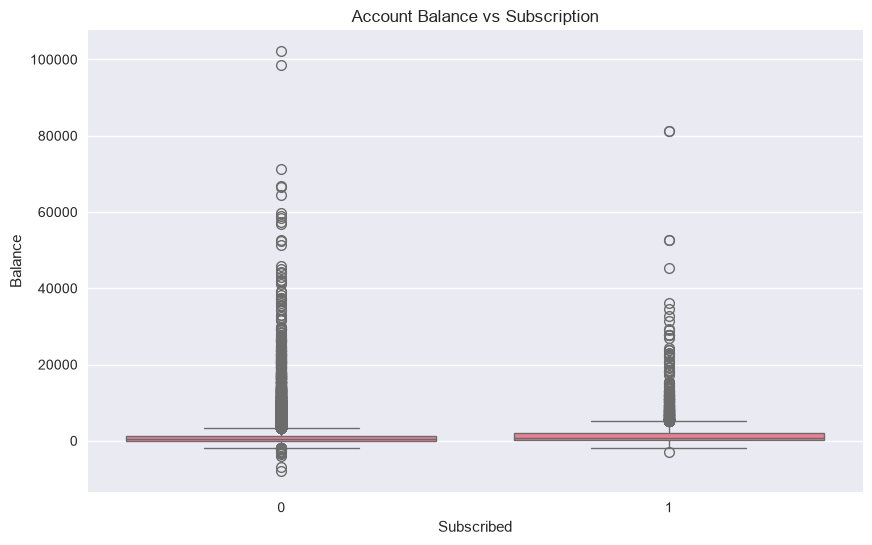


Average Balance by Subscription:
Subscribed
0    1303.71
1    1804.27
Name: balance, dtype: float64


In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Subscribed', y='balance', data=df)
plt.title('Account Balance vs Subscription')
plt.ylabel('Balance')
plt.show()

print("\nAverage Balance by Subscription:")
print(df.groupby('Subscribed')['balance'].mean().round(2))

### Key Insight
### Customers who subscribed have a noticeably higher average balance (£1,804 vs £1,304). Higher-balance customers are more likely to convert, suggesting the campaign resonates better with financially stable prospects.

## Housing & Loan Impact

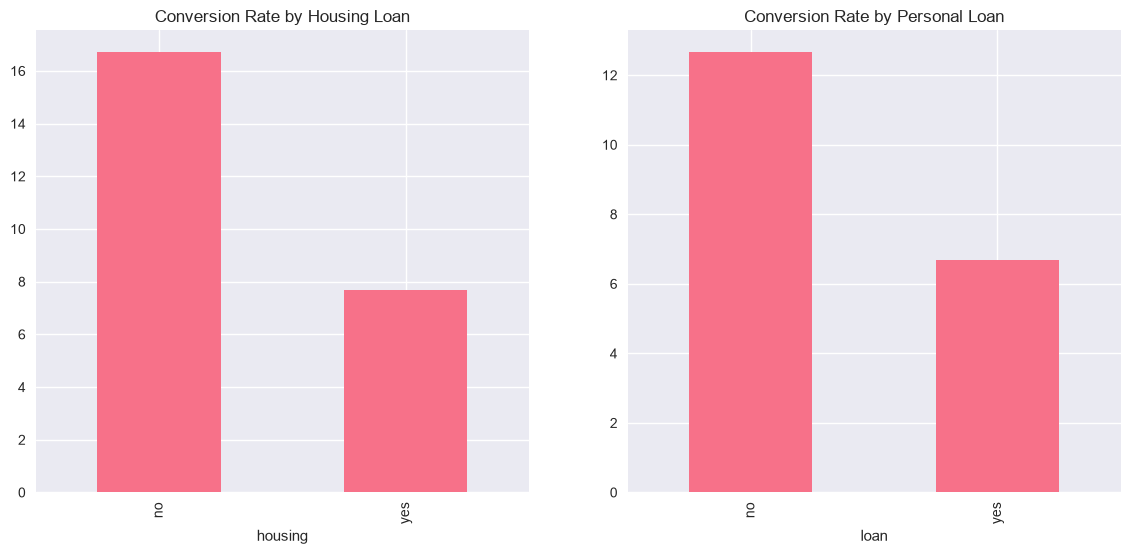

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

housing_conv = df.groupby('housing')['Subscribed'].mean() * 100
loan_conv = df.groupby('loan')['Subscribed'].mean() * 100

housing_conv.plot(kind='bar', ax=axes[0])
loan_conv.plot(kind='bar', ax=axes[1])

axes[0].set_title('Conversion Rate by Housing Loan')
axes[1].set_title('Conversion Rate by Personal Loan')
plt.show()

### Key Insight
### Customers without a housing loan convert at nearly double the rate (16.3% vs 7.9%). Similarly, those without a personal loan perform better. Debt burden appears to be a significant barrier to subscription.

## Campaign Behavior & Time Analysis

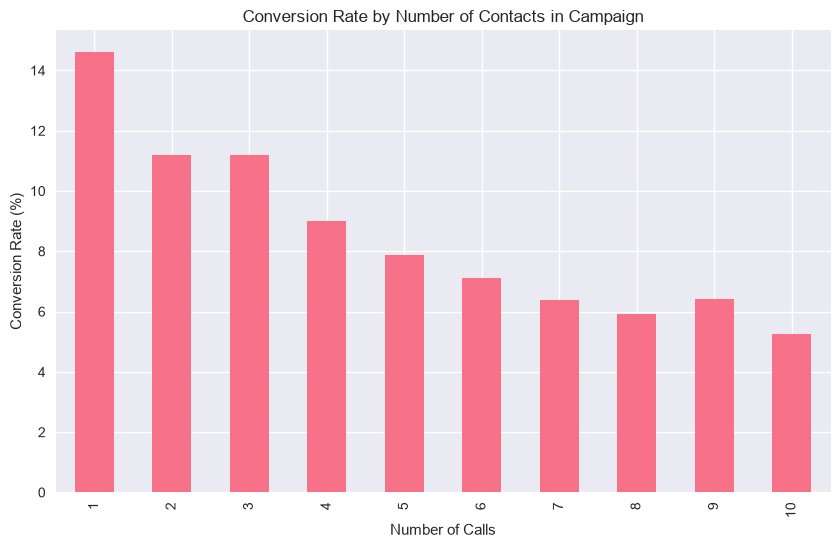

Conversion Rate by Number of Campaign Contacts (first 10):
campaign
1     14.60
2     11.20
3     11.19
4      9.00
5      7.88
6      7.13
7      6.39
8      5.93
9      6.42
10     5.26
Name: Subscribed, dtype: float64


In [19]:
# 1. Number of Contacts (Campaign) vs Conversion
plt.figure(figsize=(10, 6))
campaign_conv = df.groupby('campaign')['Subscribed'].mean() * 100
campaign_conv.head(10).plot(kind='bar')
plt.title('Conversion Rate by Number of Contacts in Campaign')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Number of Calls')
plt.show()

print("Conversion Rate by Number of Campaign Contacts (first 10):")
print(campaign_conv.head(10).round(2))

### Key Insight
### Conversion rate is highest on the first contact (14.6%) and declines steadily with more calls. This suggests the campaign is most effective early on — excessive follow-ups may lead to diminishing returns or annoyance.

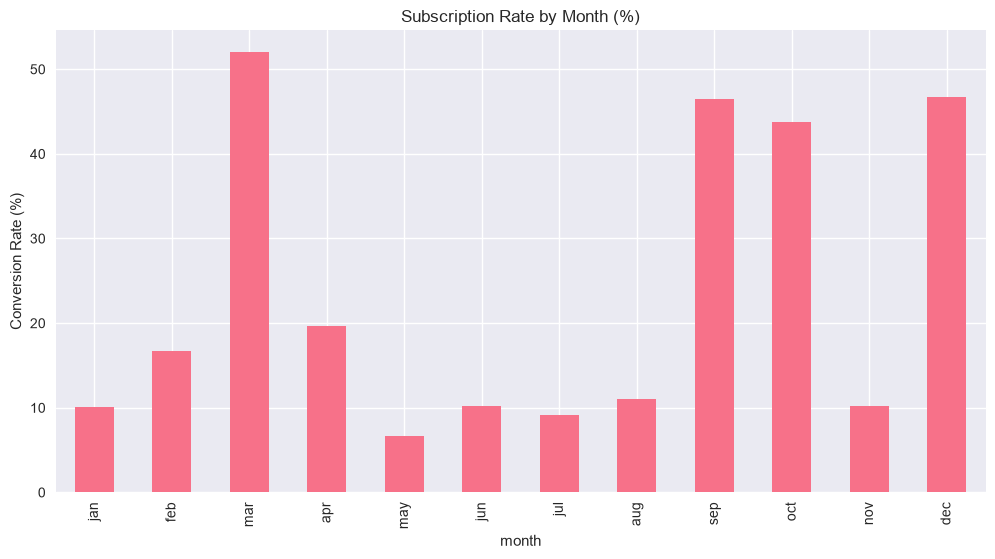


Best Months by Conversion Rate:
month
mar    51.99
dec    46.73
sep    46.46
oct    43.77
apr    19.68
feb    16.65
aug    11.01
jun    10.22
nov    10.15
jan    10.12
jul     9.09
may     6.72
Name: Subscribed, dtype: float64


In [20]:
# 2. Conversion by Month
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))
month_conv = df.groupby('month')['Subscribed'].mean() * 100
month_conv.plot(kind='bar')
plt.title('Subscription Rate by Month (%)')
plt.ylabel('Conversion Rate (%)')
plt.show()

print("\nBest Months by Conversion Rate:")
print(month_conv.sort_values(ascending=False).round(2))

### Key Insight
### March, December, September, and October show the strongest performance (conversion rates 20–52%), while May is the weakest (6.7%). Seasonal timing plays a major role in campaign success.

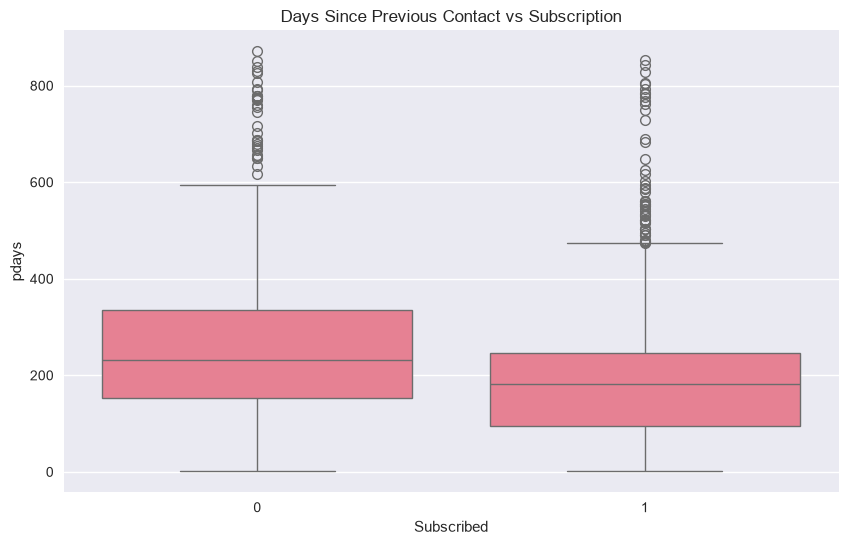

In [21]:
# 3. Previous Contacts (pdays & previous)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Subscribed', y='pdays', data=df[df['pdays'] > -1])
plt.title('Days Since Previous Contact vs Subscription')
plt.show()

### Key Insight
### Shorter gaps since the previous contact tend to yield better re-engagement results. This reinforces the value of timely follow-ups rather than long waiting periods.

## Overall Summary Table

In [22]:
summary = {
    'Metric': ['Total Contacts', 'Overall Conversion Rate', 'Successful Subscriptions'],
    'Value': [len(df), f"{df['Subscribed'].mean()*100:.2f}%", df['Subscribed'].sum()]
}

print(pd.DataFrame(summary))

                     Metric   Value
0            Total Contacts   45211
1   Overall Conversion Rate  11.70%
2  Successful Subscriptions    5289


##  SUMMARY OF MAJOR FINDINGS
### Overall conversion rate is 11.7% (5,289 successful subscriptions out of 45,211 contacts).
### Age and previous campaign outcome are among the strongest predictors of success.
### Cellular contact, longer call duration, and no housing loan significantly improve conversion.
### Students, retirees, and higher-balance customers are high-value segments.
### Conversion drops sharply with repeated contacts and varies strongly by month.

##  RECOMMENDATIONS
### Prioritize high-potential segments: Focus future campaigns on students, retirees, and customers aged 60+.
### Improve contact quality: Ensure mobile numbers are up to date and train agents to sustain meaningful conversations.
### Re-engagement strategy: Aggressively target customers with previous successful outcomes.
### Timing matters: Schedule major campaigns in March, September, October, and December.
### Target financially stable customers: Develop tailored messaging for customers without housing/personal loans and with higher balances.
### Avoid over-contacting: Limit follow-up calls — first contact is most effective.
### Test personalized offers: Create job-specific and life-stage-specific messaging to boost relevance.